In [1]:
import sys
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.models import load_model
import pickle, gzip

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-27 02:56:04.849521: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 02:56:05.014269: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-27 02:56:05.080461: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-27 02:56:05.101111: E external/l

In [2]:
ROOT_DIR = Path.cwd().parents[1]
sys.path.append(str(ROOT_DIR / "src" / "data_preprocessing"))
from normalize_fn import load
model_file  = ROOT_DIR / "src" / "model_training" / "checkpoints" / "final_model.h5"
features_file = ROOT_DIR / "datasets" / "Feature_vectors_dataset.p.gz"
results_dir = ROOT_DIR / "src" / "shap" / "shap_result_1000"
results_dir.mkdir(parents=True, exist_ok=True)

In [3]:
norm = 'norm'
model = load_model(str(model_file))
train_features, _, _, test_features, _, _, _, _ = load(norm=norm)

I0000 00:00:1772160967.759107     595 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772160968.060191     595 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772160968.060233     595 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772160968.062476     595 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772160968.062508     595 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

In [4]:
with gzip.open(features_file, 'rb') as f:
    features_df = pickle.load(f)
non_feature_cols = [c for c in ['Unnamed: 0', 'synergy', 'fold', 'drug_a_name', 'drug_b_name', 'cell_line']
                    if c in features_df.columns]
features_df = features_df.drop(columns=non_feature_cols)

In [5]:
raw_train = features_df.to_numpy(np.float32)
labels_df = pd.read_csv(ROOT_DIR / "datasets" / "labels.csv")
train_idx = np.where((labels_df['fold'] != 0) & (labels_df['fold'] != 1))[0]
X_tr_raw = raw_train[train_idx]
std1_raw = np.nanstd(X_tr_raw, axis=0)
feat_filt = std1_raw > 1e-8
feature_names = np.array(features_df.columns.tolist())[feat_filt]
print(f"Number of features after filtering: {len(feature_names)}")

Number of features after filtering: 7060


In [6]:
seed_results = {}
for seed in [42, 123, 456]:
    np.random.seed(seed)
    bg_idx      = np.random.choice(len(train_features), size=1000, replace=False)
    test_idx    = np.random.choice(len(test_features), size=500, replace=False)
    background  = train_features[bg_idx].astype(np.float32)
    test_sample = test_features[test_idx].astype(np.float32)

    explainer   = shap.DeepExplainer(model, background)
    shap_values = explainer.shap_values(test_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.array(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature'   : feature_names,
        'Mean_SHAP' : mean_abs_shap
    }).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

    top5 = importance_df.head(5)
    seed_results[seed] = top5
    print(f"\nSeed {seed} - Top 5 Global Features:")
    print(top5.to_string(index=False))


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+p


Seed 42 - Top 5 Global Features:
         Feature  Mean_SHAP
          B_Qmin   0.034153
A_ECFP_ECFP6_295   0.033339
A_ECFP_ECFP6_127   0.032925
A_ECFP_ECFP6_267   0.032411
A_ECFP_ECFP6_377   0.032131


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(



Seed 123 - Top 5 Global Features:
         Feature  Mean_SHAP
          B_Qmin   0.034195
B_ECFP_ECFP6_435   0.032460
B_ECFP_ECFP6_767   0.031967
A_ECFP_ECFP6_295   0.029937
A_ECFP_ECFP6_127   0.028935


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(



Seed 456 - Top 5 Global Features:
         Feature  Mean_SHAP
          B_Qmin   0.035688
B_ECFP_ECFP6_435   0.034804
B_ECFP_ECFP6_767   0.034283
A_ECFP_ECFP6_295   0.031114
A_ECFP_ECFP6_127   0.030888


In [7]:
consistent = set(   ['Feature']) & set(seed_results[123]['Feature']) & set(seed_results[456]['Feature'])
print(f"\nFeatures consistent across all 3 seeds: {consistent}")


Features consistent across all 3 seeds: set()


In [8]:
top5_res = seed_results[42]
with open(results_dir / "shap_top5_features.txt", "w") as f:
    f.write("Top 5 Global Features by Mean Absolute SHAP Value (Seed 42)\n")
    f.write("=" * 60 + "\n\n")
    for i, row in top5_res.iterrows():
        f.write(f"Rank {i+1}: {row['Feature']}\n")
        f.write(f"  Mean |SHAP| : {row['Mean_SHAP']:.6f}\n\n")

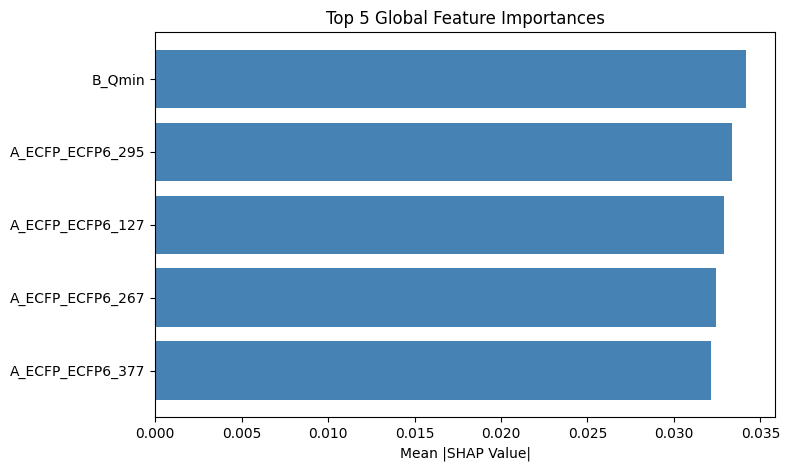

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top5_res['Feature'][::-1], top5_res['Mean_SHAP'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 5 Global Feature Importances')
plt.savefig(results_dir / 'shap_top5_bar.png', dpi=150)
plt.show()

In [10]:
top5_res_idx = [feature_names.index(f) for f in top5_res['Feature']]

shap.summary_plot(
    shap_values[:, top5_res_idx],
    test_sample[:, top5_res_idx],
    feature_names=top5_res['Feature'].tolist(),
    show=False
)
plt.tight_layout()
plt.savefig(results_dir / 'shap_summary_plot.png', dpi=150)
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'index'